In [156]:
# ====================================================================
# Three-Class Classification: Drinking, Eating, Not_Drinking
# ====================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tcn import TCN
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
rng = np.random.default_rng(76)
tf.keras.utils.set_random_seed(76)
tf.debugging.enable_check_numerics()

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [157]:
# How many eating sequences do I have *before* concatenation?
eating_raw = pd.read_excel("eating_sequence_processed.xlsx")

print("Unique sip_id in raw file :", eating_raw['sip_id'].nunique())
print("Top 5 sip_id counts\n", eating_raw['sip_id'].value_counts().head())

Unique sip_id in raw file : 15
Top 5 sip_id counts
 sip_id
4    3784
2    3404
3    3320
5    3001
1    2820
Name: count, dtype: int64


In [158]:
# ====================================================================
# Load and combine drinking and eating data (sip-based approach)
# ====================================================================

# Load drinking data files
DRINKING_FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "previous_dv0_withstraw_sipCAdded.xlsx",
    "dv0_withoutstraw_sipCAdded.xlsx",
     
    "dv0_withstraw_sipCAdded.xlsx",
]

# Load and combine drinking data (same as before)
drinking_dfs = []
next_offset = 0

for fp in DRINKING_FILES:
    df = pd.read_excel(fp)
    
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp}: original IDs {old_min} … {old_max}")
    
    df["Participant_ID"] += next_offset
    next_offset = df["Participant_ID"].max() + 1
    
    drinking_dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")

drinking_combined = pd.concat(drinking_dfs, ignore_index=True)
print(f"\nDrinking data shape: {drinking_combined.shape}")

# Load eating data with sip_id
eating_data = pd.read_excel("eating_sequence_processed.xlsx")
print(f"Eating data shape: {eating_data.shape}")

# Shift eating Participant_IDs to avoid conflicts
eating_offset = drinking_combined['Participant_ID'].max() + 1
eating_data['Participant_ID'] += eating_offset
print(f"Eating Participant_IDs shifted to: {eating_data['Participant_ID'].min()} … {eating_data['Participant_ID'].max()}")

previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
previous_dv0_withstraw_sipCAdded.xlsx: original IDs 9 … 59
   shifted to 72 … 122
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 124 … 137
dv0_withstraw_sipCAdded.xlsx: original IDs 1 … 5
   shifted to 139 … 143

Drinking data shape: (134974, 82)
Eating data shape: (25872, 68)
Eating Participant_IDs shifted to: 145 … 170


In [159]:
# ====================================================================
# Prepare combined data for three-class classification (sip-based)
# ====================================================================

# Select relevant columns from drinking data
drinking_features = drinking_combined.iloc[:, 2:66]  # Skip Participant_ID and Label columns
drinking_features['Participant_ID'] = drinking_combined['Participant_ID']
drinking_features['Label'] = drinking_combined['Label']
drinking_features['sip_id'] = drinking_combined['sip_id']
drinking_features['dV'] = drinking_combined['dV']

# Remove time column from eating data if it exists
if 'Time' in eating_data.columns:
    eating_data_no_time = eating_data.drop('Time', axis=1)
else:
    eating_data_no_time = eating_data

# Ensure column alignment
print("Drinking data columns:", drinking_features.columns.tolist())
print("Eating data columns:", eating_data_no_time.columns.tolist())

# Combine drinking and eating data
all_data = pd.concat([drinking_features, eating_data_no_time], ignore_index=True)
print(f"\nCombined data shape: {all_data.shape}")

# Fix label mapping to handle both numeric and string labels
def map_label_to_three_class(label):
    if pd.isna(label):
        return np.nan
    
    # Handle string labels
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels
    elif isinstance(label, (int, float)):
        if label == 0:
            return 0  # Not_Drinking
        elif label == 1:
            return 1  # Drinking
        else:
            return np.nan
    
    return np.nan

# Apply the mapping
all_data['Three_Class_Label'] = all_data['Label'].apply(map_label_to_three_class)

print("\nThree-class label distribution:")
print(all_data['Three_Class_Label'].value_counts().sort_index())
print(f"NaN values: {all_data['Three_Class_Label'].isna().sum()}")

# Remove rows with NaN labels
all_data = all_data.dropna(subset=['Three_Class_Label'])
print(f"Data shape after removing NaN: {all_data.shape}")

Drinking data columns: ['Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_20', 'Zone_21', 'Zone_22', 'Zone_23', 'Zone_24', 'Zone_25', 'Zone_26', 'Zone_27', 'Zone_28', 'Zone_29', 'Zone_30', 'Zone_31', 'Zone_32', 'Zone_33', 'Zone_34', 'Zone_35', 'Zone_36', 'Zone_37', 'Zone_38', 'Zone_39', 'Zone_40', 'Zone_41', 'Zone_42', 'Zone_43', 'Zone_44', 'Zone_45', 'Zone_46', 'Zone_47', 'Zone_48', 'Zone_49', 'Zone_50', 'Zone_51', 'Zone_52', 'Zone_53', 'Zone_54', 'Zone_55', 'Zone_56', 'Zone_57', 'Zone_58', 'Zone_59', 'Zone_60', 'Zone_61', 'Zone_62', 'Zone_63', 'Participant_ID', 'Label', 'sip_id', 'dV']
Eating data columns: ['Zone_0', 'Zone_1', 'Zone_2', 'Zone_3', 'Zone_4', 'Zone_5', 'Zone_6', 'Zone_7', 'Zone_8', 'Zone_9', 'Zone_10', 'Zone_11', 'Zone_12', 'Zone_13', 'Zone_14', 'Zone_15', 'Zone_16', 'Zone_17', 'Zone_18', 'Zone_19', 'Zone_2

In [160]:
# ====================================================================
# Fix the label mapping to handle both numeric and string labels CORRECTLY
# ====================================================================

def map_label_to_three_class_corrected(row):
    """
    Correctly map labels to three-class system.
    For drinking data: 0=Not_Drinking, 1=Drinking
    For eating data: Not_Drinking=Not_Drinking, Eating=Eating
    """
    label = row['Label']
    participant_id = row['Participant_ID']
    
    # Check if this is drinking data (lower participant IDs)
    is_drinking_data = participant_id < 100
    
    if pd.isna(label):
        return np.nan
    
    # Handle string labels (eating data)
    if isinstance(label, str):
        if label == 'Not_Drinking':
            return 0
        elif label == 'Drinking':
            return 1
        elif label == 'Eating':
            return 2
        else:
            return np.nan
    
    # Handle numeric labels (drinking data)
    elif isinstance(label, (int, float)):
        if is_drinking_data:
            # For drinking data: 0=Not_Drinking, 1=Drinking
            if label == 0:
                return 0  # Not_Drinking
            elif label == 1:
                return 1  # Drinking
            else:
                return np.nan
        else:
            # For eating data with numeric labels (shouldn't happen but just in case)
            return np.nan
    
    return np.nan

# Apply the corrected mapping
all_data['Three_Class_Label'] = all_data.apply(map_label_to_three_class_corrected, axis=1)

print("\nThree-class label distribution after CORRECTED mapping:")
print(all_data['Three_Class_Label'].value_counts().sort_index())
print(f"NaN values remaining: {all_data['Three_Class_Label'].isna().sum()}")

# Check the mapping worked correctly
print("\nSample of corrected mapped labels:")
sample_data = all_data[['Participant_ID', 'Label', 'Three_Class_Label']].head(20)
display(sample_data)


Three-class label distribution after CORRECTED mapping:
Three_Class_Label
0.0    106987
1.0      6572
2.0      1610
Name: count, dtype: int64
NaN values remaining: 45677

Sample of corrected mapped labels:


,Participant_ID,Label,Three_Class_Label
0,6,0,0.0
1,6,0,0.0
2,6,0,0.0
3,6,0,0.0
4,6,0,0.0
5,6,0,0.0
6,6,0,0.0
7,6,0,0.0
8,6,0,0.0
9,6,0,0.0


In [161]:
# ====================================================================
# Filter drinking data for zero dV (but keep all eating data)
# ====================================================================

def filter_drinking_data(df):
    """
    Filter drinking data to remove zero dV sips, but keep all eating data.
    """
    filtered_data = []
    
    for _, group in df.groupby(['Participant_ID', 'sip_id', 'Label']):
        label = group['Label'].iloc[0]
        
        # For drinking data, check dV
        if label == 'Drinking' and 'dV' in group.columns:
            dV = float(group['dV'].iloc[0])
            if dV == 0.0:
                continue  # Skip zero dV drinking sips
        
        # Keep all eating and Not_Drinking data
        filtered_data.append(group)
    
    return pd.concat(filtered_data, ignore_index=True)

# Apply filtering to drinking data only
print("Filtering drinking data for zero dV...")
all_data_filtered = filter_drinking_data(all_data)

print(f"Original data shape: {all_data.shape}")
print(f"Filtered data shape: {all_data_filtered.shape}")
print(f"Rows removed: {len(all_data) - len(all_data_filtered)}")

# Use filtered data for sequence creation
all_data = all_data_filtered

Filtering drinking data for zero dV...
Original data shape: (160846, 69)
Filtered data shape: (160846, 69)
Rows removed: 0


In [162]:
# ====================================================================
# Create sip-based sequences (STANDARD APPROACH like combined_classification.ipynb)
# ====================================================================

def create_sip_sequences_simple(df):
    """
    Create sequences using simple approach like the original combined_classification.ipynb
    """
    sequences = []
    labels = []
    participant_ids = []
    sip_ids = []
    
    # Group by Participant_ID, sip_id, and Label (simple approach)
    seq_keys = ["Participant_ID", "sip_id", "Label"]
    
    for _, group in df.groupby(seq_keys, sort=False):
        # Get the label for this sip
        label = group["Three_Class_Label"].iloc[0]
        
        # Skip if label is NaN
        if pd.isna(label):
            continue
            
        # For drinking data, check dV (skip zero dV drinking sips)
        if group["Label"].iloc[0] == 1 and "dV" in group.columns:
            dV = float(group["dV"].iloc[0])
            if dV == 0.0:
                continue  # Skip zero dV drinking sips
        
        # Get the feature data for this sip
        feature_cols = [col for col in group.columns if col.startswith('Zone_')]
        sip_data = group[feature_cols].to_numpy(np.float32)  # (T, 64)
        
        # Include all sips (no minimum length filter)
        sequences.append(sip_data)
        labels.append(int(label))
        participant_ids.append(group["Participant_ID"].iloc[0])
        sip_ids.append(group["sip_id"].iloc[0])
    
    return sequences, np.array(labels, dtype=np.int32), np.array(participant_ids), np.array(sip_ids)
# Create sequences using standard approach
print("Creating sip-based sequences using standard approach...")
X_sequences, y_sequences, participant_ids, sip_ids = create_sip_sequences_simple(all_data)
print(f"Total sequences: {len(X_sequences)}")
print(f"Label distribution: {np.bincount(y_sequences)}")
print(f"Unique participants: {len(np.unique(participant_ids))}")

# Show class distribution
print("\nClass distribution:")
class_names = ["Not_Drinking", "Drinking", "Eating"]
for i, name in enumerate(class_names):
    count = (y_sequences == i).sum()
    print(f"  {name}: {count}")

# Check by data type
print("\nSequences by data type:")
drinking_sequences = sum(1 for p in participant_ids if p < 100)  # Drinking data
eating_sequences = sum(1 for p in participant_ids if p >= 100)   # Eating data

print(f"  Drinking sequences: {drinking_sequences}")
print(f"  Eating sequences: {eating_sequences}")

# Show sample sequences
print(f"\nSample sequences:")
for i in range(min(3, len(X_sequences))):
    print(f"Sequence {i}: shape {X_sequences[i].shape}, label {y_sequences[i]}, participant {participant_ids[i]}, sip_id {sip_ids[i]}")

# Check by participant
print(f"\nSequences by participant (first 10):")
participant_counts = {}
for participant_id in participant_ids:
    if participant_id not in participant_counts:
        participant_counts[participant_id] = 0
    participant_counts[participant_id] += 1

for i, (participant_id, count) in enumerate(sorted(participant_counts.items())):
    if i < 10:  # Show first 10
        print(f"  Participant {participant_id}: {count} sequences")
    else:
        break

Creating sip-based sequences using standard approach...
Total sequences: 1204
Label distribution: [639 375 190]
Unique participants: 72

Class distribution:
  Not_Drinking: 639
  Drinking: 375
  Eating: 190

Sequences by data type:
  Drinking sequences: 798
  Eating sequences: 406

Sample sequences:
Sequence 0: shape (241, 64), label 0, participant 6, sip_id 0
Sequence 1: shape (83, 64), label 0, participant 6, sip_id 1
Sequence 2: shape (26, 64), label 1, participant 6, sip_id 1

Sequences by participant (first 10):
  Participant 6: 13 sequences
  Participant 7: 15 sequences
  Participant 8: 13 sequences
  Participant 10: 17 sequences
  Participant 11: 17 sequences
  Participant 13: 25 sequences
  Participant 14: 21 sequences
  Participant 16: 29 sequences
  Participant 17: 13 sequences
  Participant 19: 9 sequences


In [163]:
# ====================================================================
# DEBUG: Check data loading and label mapping
# ====================================================================

print("=== DEBUGGING DATA LOADING AND LABELS ===")

# Check the original drinking data
print("\n1. ORIGINAL DRINKING DATA:")
print(f"Drinking combined shape: {drinking_combined.shape}")
print(f"Drinking data labels: {drinking_combined['Label'].value_counts()}")

# Check the original eating data
print("\n2. ORIGINAL EATING DATA:")
print(f"Eating data shape: {eating_data.shape}")
print(f"Eating data labels: {eating_data['Label'].value_counts()}")

# Check the combined data
print("\n3. COMBINED DATA:")
print(f"All data shape: {all_data.shape}")
print(f"All data labels: {all_data['Label'].value_counts()}")

# Check the three-class mapping
print("\n4. THREE-CLASS MAPPING:")
print(f"Three-class labels: {all_data['Three_Class_Label'].value_counts().sort_index()}")

# Check if drinking data has dV column
print("\n5. DRINKING DATA dV CHECK:")
if 'dV' in drinking_combined.columns:
    print(f"dV column exists in drinking data")
    print(f"dV values: {drinking_combined['dV'].value_counts().head()}")
else:
    print("❌ dV column missing from drinking data!")

# Check participant IDs
print("\n6. PARTICIPANT ID RANGES:")
print(f"Drinking Participant_IDs: {drinking_combined['Participant_ID'].min()} to {drinking_combined['Participant_ID'].max()}")
print(f"Eating Participant_IDs: {eating_data['Participant_ID'].min()} to {eating_data['Participant_ID'].max()}")

# Check if drinking data is being filtered out during combination
print("\n7. CHECKING FOR DRINKING DATA IN COMBINED:")
drinking_in_combined = all_data[all_data['Participant_ID'] < 100]  # Drinking data should have lower IDs
print(f"Drinking data in combined: {len(drinking_in_combined)} rows")
print(f"Drinking labels in combined: {drinking_in_combined['Label'].value_counts()}")

=== DEBUGGING DATA LOADING AND LABELS ===

1. ORIGINAL DRINKING DATA:
Drinking combined shape: (134974, 82)
Drinking data labels: Label
0    124262
1     10712
Name: count, dtype: int64

2. ORIGINAL EATING DATA:
Eating data shape: (25872, 68)
Eating data labels: Label
Not_Drinking    24262
Eating           1610
Name: count, dtype: int64

3. COMBINED DATA:
All data shape: (160846, 69)
All data labels: Label
0               124262
Not_Drinking     24262
1                10712
Eating            1610
Name: count, dtype: int64

4. THREE-CLASS MAPPING:
Three-class labels: Three_Class_Label
0.0    106987
1.0      6572
2.0      1610
Name: count, dtype: int64

5. DRINKING DATA dV CHECK:
dV column exists in drinking data
dV values: dV
0.000000      124264
100.000000       297
99.206349        223
80.000000        215
60.000000        184
Name: count, dtype: int64

6. PARTICIPANT ID RANGES:
Drinking Participant_IDs: 6 to 143
Eating Participant_IDs: 145 to 170

7. CHECKING FOR DRINKING DATA IN COM

In [164]:
# ====================================================================
# Split data (EXACTLY like combined_classification.ipynb)
# ====================================================================
# Use the same split as combined_classification.ipynb
idx = rng.permutation(len(X_sequences))
split1 = int(.64 * len(X_sequences))          # 64 % train
split2 = int(.80 * len(X_sequences))          # next 16 % val

# Convert to numpy arrays for indexing
X_sequences_array = np.array(X_sequences, dtype=object)
y_sequences_array = np.array(y_sequences)

X_train, y_train = X_sequences_array[idx[:split1]], y_sequences_array[idx[:split1]]
X_val,   y_val   = X_sequences_array[idx[split1:split2]], y_sequences_array[idx[split1:split2]]
X_test,  y_test  = X_sequences_array[idx[split2:]], y_sequences_array[idx[split2:]]

# Convert back to lists for the rest of the pipeline
X_train = list(X_train)
X_val = list(X_val)
X_test = list(X_test)

print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")

# Check class distribution in splits
print("\nClass distribution in splits:")
print(f"Train: {np.bincount(y_train)}")
print(f"Validation: {np.bincount(y_val)}")
print(f"Test: {np.bincount(y_test)}")

Train 770 Val 193  Test 241

Class distribution in splits:
Train: [405 238 127]
Validation: [102  58  33]
Test: [132  79  30]


In [165]:
# ====================================================================
# Normalize data (EXACTLY like combined_classification.ipynb)
# ====================================================================

# Column-wise z-score normalisation (fit on training only)
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train_norm = [norm(s) for s in X_train]
X_val_norm   = [norm(s) for s in X_val]
X_test_norm  = [norm(s) for s in X_test]

# No label scaling needed for classification
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test

print("Data shapes after normalization:")
print(f"X_train: {len(X_train_norm)} sequences")
print(f"X_val: {len(X_val_norm)} sequences")
print(f"X_test: {len(X_test_norm)} sequences")

Data shapes after normalization:
X_train: 770 sequences
X_val: 193 sequences
X_test: 241 sequences


In [166]:
# ====================================================================
# Create tf.data pipelines (EXACTLY like combined_classification.ipynb)
# ====================================================================

BATCH = 1  # Use batch size 1 for variable length sequences

def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

print("Data pipelines created successfully!")

Data pipelines created successfully!


In [167]:
# ====================================================================
# Create TCN model for three-class classification (variable length)
# ====================================================================

num_classes = 3  # Not_Drinking, Drinking, Eating

# Input shape: (None, 64) - variable length sequences with 64 features
inp = tf.keras.Input(shape=(None, 64))
x = TCN(
    nb_filters=128,
    kernel_size=2,
    dilations=[1, 2, 4, 8, 16, 32],
    dropout_rate=0.1,
    return_sequences=False
)(inp)
out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inp, out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_8 (TCN)                     │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,075 (1.48 MB)

 Trainable params: 387,075 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [168]:
# ====================================================================
# Train the model (variable length sequences)
# ====================================================================

BATCH_SIZE = 1  # Use batch size 1 for variable length sequences

# Create data generators for variable length sequences
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),  # Variable length, 64 features
    tf.TensorSpec((), tf.int32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: generator(xs, ys),
        output_signature=output_sig
    )
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    return ds.repeat().batch(BATCH_SIZE)  # Ragged batches

train_ds = make_ds(X_train_norm, y_train, shuffle=True)
val_ds = make_ds(X_val_norm, y_val, shuffle=False)
test_ds = make_ds(X_test_norm, y_test, shuffle=False)

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

# Train
history = model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=len(X_train_norm),
    validation_data=val_ds,
    validation_steps=len(X_val_norm),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.7956 - loss: 3.8832 - val_accuracy: 0.8756 - val_loss: 0.5468
Epoch 2/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9146 - loss: 0.4393 - val_accuracy: 0.9534 - val_loss: 0.2447
Epoch 3/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9573 - loss: 0.1727 - val_accuracy: 0.9430 - val_loss: 0.2647
Epoch 4/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9555 - loss: 0.1598 - val_accuracy: 0.8497 - val_loss: 1.6385
Epoch 5/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9143 - loss: 0.3794 - val_accuracy: 0.9430 - val_loss: 0.2209
Epoch 6/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9730 - loss: 0.0935 - val_accuracy: 0.9430 - val_loss: 0.2152
Epoch 7/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9568 - loss: 0.1554 - val_accuracy: 0.9067 - val_loss: 0.3805
Epoch 8/50
770/770 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9525 - loss: 0.1406 - 

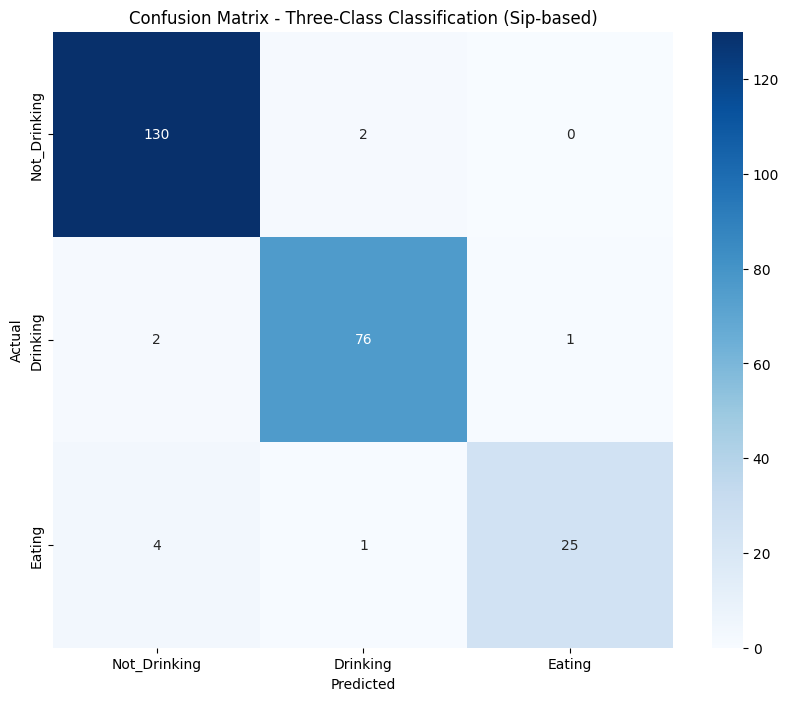


Classification Report:
              precision    recall  f1-score   support

Not_Drinking       0.96      0.98      0.97       132
    Drinking       0.96      0.96      0.96        79
      Eating       0.96      0.83      0.89        30

    accuracy                           0.96       241
   macro avg       0.96      0.93      0.94       241
weighted avg       0.96      0.96      0.96       241


Overall Metrics:
Accuracy: 0.9585
Precision: 0.9586
Recall: 0.9585
F1-Score: 0.9579


In [169]:
# ====================================================================
# Evaluate model and create confusion matrix (variable length)
# ====================================================================

# Predictions for variable length sequences
y_pred_probs = []
for seq in X_test_norm:
    pred = model.predict(seq[None, ...], verbose=0)[0]
    y_pred_probs.append(pred)

y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
class_names = ["Not_Drinking", "Drinking", "Eating"]
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Three-Class Classification (Sip-based)')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Additional metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

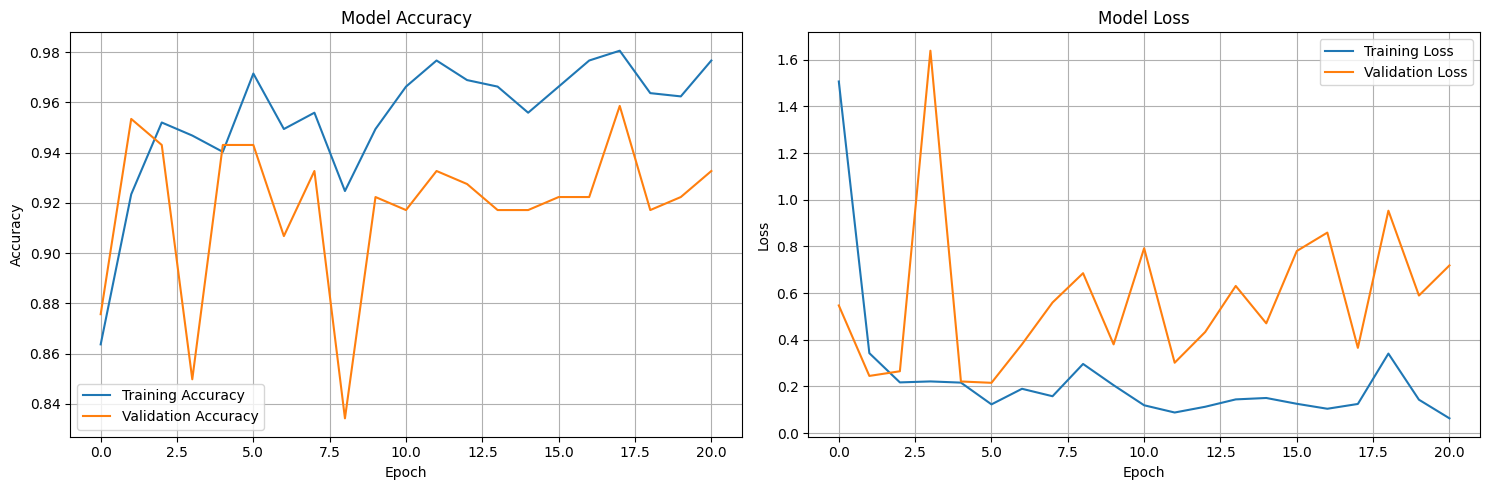

In [170]:
# ====================================================================
# Plot training history
# ====================================================================

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [171]:
# ====================================================================
# Save model and results
# ====================================================================

# Save the trained model using the newer Keras format
model.save('three_class_tcn_model.keras')
print("Model saved as 'three_class_tcn_model.keras'")

# Save predictions and results
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'True_Class': [class_names[i] for i in y_test],
    'Predicted_Class': [class_names[i] for i in y_pred]
})

results_df.to_excel('classification_results.xlsx', index=False)
print("Results saved as 'classification_results.xlsx'")

# Print final summary
print(f"\nFinal Model Performance:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Model saved as 'three_class_tcn_model.keras'
Results saved as 'classification_results.xlsx'

Final Model Performance:
Test Accuracy: 0.9585
Test Precision: 0.9586
Test Recall: 0.9585
Test F1-Score: 0.9579
